# NEX vs. CarbonPlan: distortion of the SSP245 − historical precipitation trend

This notebook checks how much downscaling distorts the **SSP245 minus historical** precipitation
trend, comparing two downscaled products against the raw CMIP6 GCM output each is built from:

- **NASA NEX-GDDP-CMIP6** (left panel) — raw input loaded directly from the public Pangeo
  CMIP6 Zarr archive on GCS (the actual source NEX downscales from), downscaled output loaded
  from the virtualized NEX-GDDP-CMIP6 icechunk store. Neither uses CarbonPlan infrastructure.
- **CarbonPlan's production dataset** (right panel) — both raw and downscaled loaded from
  CarbonPlan's internal catalog/production output.

Both panels compute the same quantity:

```
(SSP245_downscaled - historical_downscaled) - (SSP245_raw - historical_raw)
```

The calculations are structured identically across panels (same time windows, same
raw-vs-downscaled differencing, same regridding-before-differencing step); only the
data sources differ, matched to what each product actually downscales from.

This combines the CarbonPlan-side calculation from the [trend-distortion check](../../../docs/explanation/qa-qc/trend-distortion-check.ipynb) with the
NEX data-loading approach from `../rsds/diagnose_grid_artifacts.ipynb`.

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import icechunk
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
from obstore.store import from_url
from zarr.storage import ObjectStore

from srm import catalog
from srm.downscaling_utils import interpolate_fine_to_coarse_grid
from srm.utils import open_icechunk

In [ ]:
import rusterize as _rusterize_mod
from rasterix.rasterize import geometry_mask

# Configuration

In [2]:
var = "pr"
unit_conv_annual = 86400 * 365  # kg m-2 s-1 -> mm/yr

# --- Time windows (shared across both panels) ---
slice_hist = slice("1978-01-01", "2014-12-31")
slice_fut = slice("2040-01-01", "2069-12-31")

# --- CarbonPlan production output ---
path_output = "s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output/production/CESM2-WACCM-ERA5-global.icechunk"
branch = "v0.12.0"
cp_ssp_ens = "008"
cp_hist_ens = "r3i1p1f1"

# --- NASA NEX-GDDP-CMIP6 ---
# NEX-GDDP-CMIP6 downscales a single realization per GCM/scenario; for CESM2-WACCM
# that's r3i1p1f1 (see src/srm/input_data/nasa_nex.py). Used as the member_id when
# pulling the matching raw realization from the public Pangeo CMIP6 archive below.
nex_ens = "r3i1p1f1"

vmax_distortion = 200  # mm/yr, shared color scale for the final comparison figure

# Load data

## CarbonPlan production (raw + downscaled)

In [3]:
# Raw CMIP6 archive, via CarbonPlan's internal processed catalog
raw_data = catalog.get("CESM2-WACCM").to_xarray()

cp_raw_historical = raw_data["historical"][var].sel(ensemble_member=cp_hist_ens)
cp_raw_ssp = raw_data["ssp245"][var].sel(ensemble_member=cp_ssp_ens)

# Downscaled, debiased production output
cp_downscaled_historical = open_icechunk(
    path=path_output, branch=branch, group=f"historical/{var}/{cp_hist_ens}"
)[var]
cp_downscaled_ssp = open_icechunk(
    path=path_output, branch=branch, group=f"ssp245/{var}/{cp_ssp_ens}"
)[var]

## NASA NEX-GDDP-CMIP6 (raw + downscaled)

In [4]:
def load_pangeo_cmip6(source_id, experiment_id, member_id, variable_id, table_id="day"):
    """Load a CMIP6 variable directly from the public Pangeo CMIP6 Zarr archive on GCS.

    This is the raw, un-downscaled GCM output -- the actual input NEX-GDDP-CMIP6 downscales
    from -- independent of any CarbonPlan-internal copy of the archive.
    """
    catalog_csv = "https://storage.googleapis.com/cmip6/pangeo-cmip6.csv"
    df = pd.read_csv(catalog_csv, low_memory=False)

    row = df[
        (df.source_id == source_id)
        & (df.experiment_id == experiment_id)
        & (df.member_id == member_id)
        & (df.variable_id == variable_id)
        & (df.table_id == table_id)
    ]
    zstore_url = row.zstore.iloc[0]

    gcs_store = from_url(zstore_url, skip_signature=True)
    zarr_store = ObjectStore(gcs_store)

    ds = xr.open_dataset(zarr_store, engine="zarr", consolidated=True, chunks="auto")
    return ds[variable_id]


# Raw CMIP6 archive, at the realization NEX-GDDP-CMIP6 downscales from
nex_raw_historical = load_pangeo_cmip6(
    source_id="CESM2-WACCM", experiment_id="historical", member_id=nex_ens, variable_id=var
)
nex_raw_ssp = load_pangeo_cmip6(
    source_id="CESM2-WACCM", experiment_id="ssp245", member_id=nex_ens, variable_id=var
)

# NEX's downscaled product, via the virtualized NEX-GDDP-CMIP6 icechunk datatree
nex_storage = icechunk.s3_storage(
    bucket="carbonplan-share",
    prefix="nasa-nex-virtual/nasa-nex-gddp-cmip6.icechunk",
    from_env=True,
)
nex_authorize = icechunk.containers_credentials(
    {"s3://nex-gddp-cmip6/": icechunk.s3_anonymous_credentials()}
)
nex_repo = icechunk.Repository.open(nex_storage, authorize_virtual_chunk_access=nex_authorize)
nex_session = nex_repo.readonly_session("main")
# note: pass decode_times=False if cftime isn't available in your environment.
nex_dt = xr.open_datatree(nex_session.store, engine="zarr", consolidated=False)

nex_downscaled_historical = nex_dt["CESM2-WACCM"]["historical"][var]
nex_downscaled_ssp = nex_dt["CESM2-WACCM"]["ssp245"][var]

# Compute distortion

`(SSP245_downscaled - historical_downscaled) - (SSP245_raw - historical_raw)`

In [5]:
def calculate_aggregate_stat(da, time_slice, unit_conv):
    """Time-mean over `time_slice`, converted to annual units."""
    return (da.sel(time=time_slice).mean(dim="time") * unit_conv).compute()


def compute_trend_distortion(
    raw_historical, raw_ssp, downscaled_historical, downscaled_ssp, unit_conv
):
    """(SSP245 - historical) for the downscaled product minus the same for the raw archive.

    The downscaled averages are interpolated onto the raw grid before differencing so the
    two terms are comparable.
    """
    raw_hist_avg = calculate_aggregate_stat(raw_historical, slice_hist, unit_conv)
    raw_ssp_avg = calculate_aggregate_stat(raw_ssp, slice_fut, unit_conv)
    downscaled_hist_avg = calculate_aggregate_stat(downscaled_historical, slice_hist, unit_conv)
    downscaled_ssp_avg = calculate_aggregate_stat(downscaled_ssp, slice_fut, unit_conv)

    coarsened_downscaled_hist_avg = interpolate_fine_to_coarse_grid(
        da_fine_to_coarsen=downscaled_hist_avg, da_coarse_grid=raw_hist_avg
    ).compute()
    coarsened_downscaled_ssp_avg = interpolate_fine_to_coarse_grid(
        da_fine_to_coarsen=downscaled_ssp_avg, da_coarse_grid=raw_hist_avg
    ).compute()

    delta_raw = raw_ssp_avg - raw_hist_avg
    delta_downscaled = coarsened_downscaled_ssp_avg - coarsened_downscaled_hist_avg

    return delta_downscaled - delta_raw

In [6]:
distortion_nex = compute_trend_distortion(
    raw_historical=nex_raw_historical,
    raw_ssp=nex_raw_ssp,
    downscaled_historical=nex_downscaled_historical,
    downscaled_ssp=nex_downscaled_ssp,
    unit_conv=unit_conv_annual,
)

distortion_cp = compute_trend_distortion(
    raw_historical=cp_raw_historical,
    raw_ssp=cp_raw_ssp,
    downscaled_historical=cp_downscaled_historical,
    downscaled_ssp=cp_downscaled_ssp,
    unit_conv=unit_conv_annual,
)

# Final figure: NEX vs. CarbonPlan

In [11]:
da = distortion_cp

In [ ]:
# this is a fix so that I can use geoparquet here
# I am not sure why it's necessary, maybe an environment issue?

_orig_rusterize = _rusterize_mod.rusterize


def _patched_rusterize(*args, **kwargs):
    if kwargs.get("res") is not None and kwargs.get("out_shape") is not None:
        kwargs = dict(kwargs)
        kwargs.pop("res")
    return _orig_rusterize(*args, **kwargs)


_rusterize_mod.rusterize = _patched_rusterize  # run once, before geometry_mask()

In [12]:
ocean_mask_ds = catalog.get("ocean-mask")

coast = ocean_mask_ds.to_geodataframe()  # GeoDataFrame with a "geom" column of land polygons

# Build a single-timestep template matching your data's spatial grid.
# rusterize requires lat sorted descending; assign_crs is needed by rasterix/xproj.
template = da.sortby("lat", ascending=False).proj.assign_crs(spatial_ref="epsg:4326")

land_mask = ~geometry_mask(
    template, coast[["geom"]], all_touched=True, engine="rusterize", xdim="lon", ydim="lat"
).drop_vars("spatial_ref", errors="ignore")
# land_mask: True = land (keep), False = ocean (mask out)

da_land_only = da.where(land_mask)  # ocean pixels -> NaN

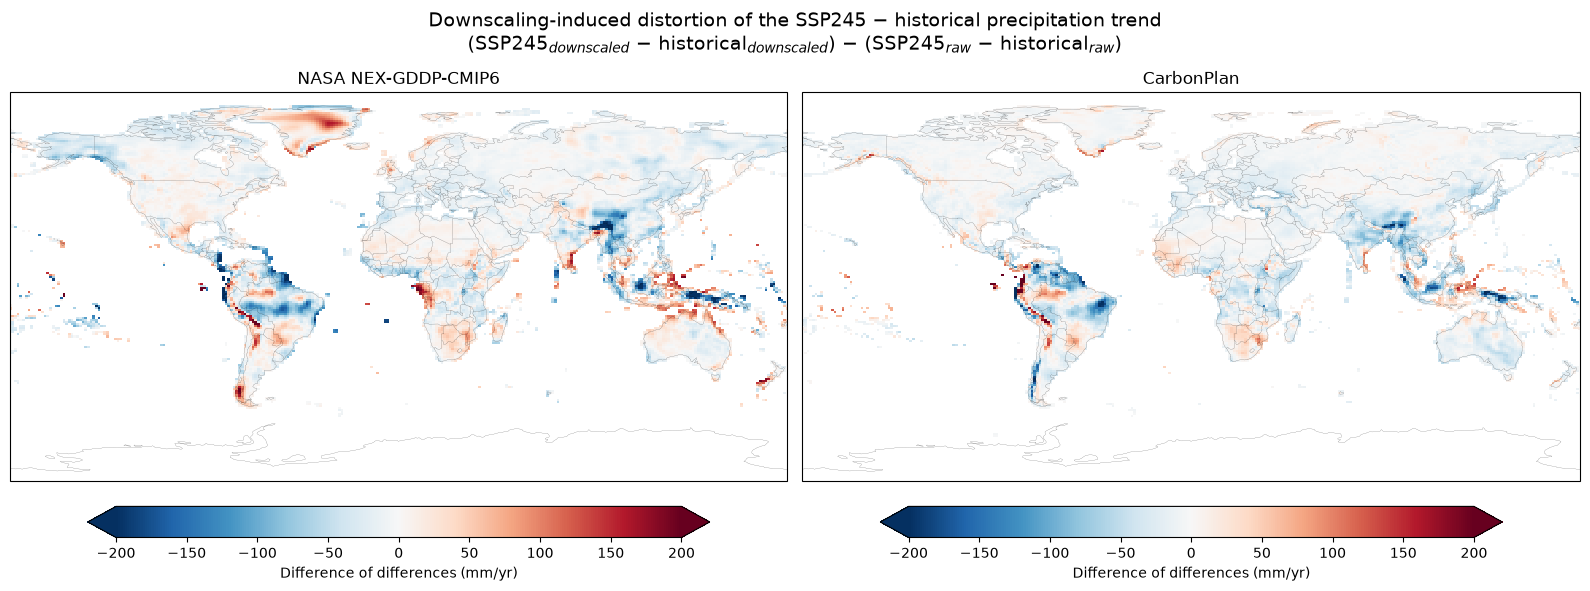

In [13]:
proj = ccrs.PlateCarree()
cbar_kwargs = {
    "orientation": "horizontal",
    "pad": 0.05,
    "shrink": 0.8,
    "label": "Difference of differences (mm/yr)",
}

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), subplot_kw={"projection": proj})

ax = axes[0]
distortion_nex.plot(
    ax=ax, vmin=-vmax_distortion, vmax=vmax_distortion, cmap=plt.cm.RdBu_r, cbar_kwargs=cbar_kwargs
)
ax.coastlines(linewidth=0.1)
ax.add_feature(cfeature.BORDERS, linewidth=0.1)
ax.set_title("NASA NEX-GDDP-CMIP6")

ax = axes[1]
da_land_only.plot(
    ax=ax, vmin=-vmax_distortion, vmax=vmax_distortion, cmap=plt.cm.RdBu_r, cbar_kwargs=cbar_kwargs
)
ax.coastlines(linewidth=0.1)
ax.add_feature(cfeature.BORDERS, linewidth=0.1)
ax.set_title("CarbonPlan")

fig.suptitle(
    "Downscaling-induced distortion of the SSP245 \u2212 historical precipitation trend\n"
    "(SSP245$_{downscaled}$ \u2212 historical$_{downscaled}$) \u2212 (SSP245$_{raw}$ \u2212 historical$_{raw}$)",
    fontsize=14,
)
plt.tight_layout()